Generating thermal configurations...
Generated 400 thermal configs
Total training examples: 480

Training...
Epoch   1: Avg loss 0.068399
Epoch  10: Avg loss 0.001513
Epoch  20: Avg loss 0.000733
Epoch  30: Avg loss 0.000544
Epoch  40: Avg loss 0.000484
Epoch  50: Avg loss 0.000419
Epoch  60: Avg loss 0.000369
Epoch  70: Avg loss 0.000344
Epoch  80: Avg loss 0.000321
Epoch  90: Avg loss 0.000304
Epoch 100: Avg loss 0.000288
Training finished.

Running standard Metropolis chain...
Running kernel-accelerated chain...
Neural proposal acceptance rate: 96.640%

Estimated tau standard : 142.74
Estimated tau kernel    : 48.75
Improvement factor      : 2.93x



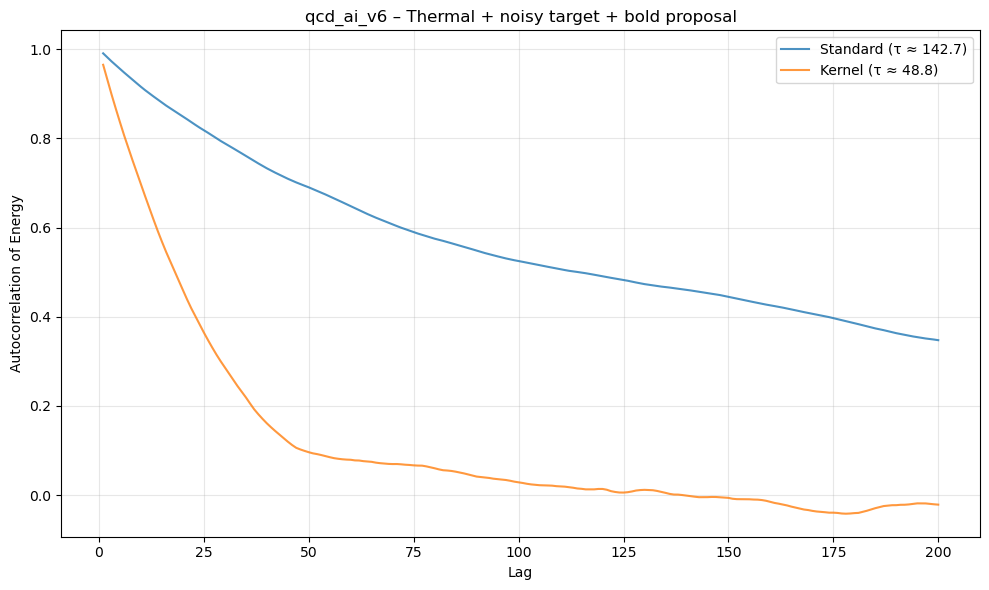

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────────────────────
# Model components
# ────────────────────────────────────────────────────────────────

class GoldstoneHyperHoloBlock(nn.Module):
    def __init__(self, dim=64, depth=5, alpha=1.7, slip_factor=0.15, ng_strength=0.1):
        super().__init__()
        self.depth = depth
        self.alpha = alpha
        self.proj = nn.Linear(dim, dim)
        self.slip_gen = nn.Linear(dim, dim)
        self.holo_proj = nn.Linear(dim * 2, dim * 4)
        self.inv_holo = nn.Linear(dim * 4, dim)
        self.ng_proj = nn.Linear(dim, dim)
        self.ng_strength = ng_strength
        self.slip_factor = slip_factor
        self.norm_h = nn.LayerNorm(dim)
        self.norm_out = nn.LayerNorm(dim)

    def forward(self, x, level=0, t_step=0.0):
        if level >= self.depth:
            return x

        slip = torch.tanh(self.slip_gen(x)) * self.slip_factor
        h = torch.relu(self.proj(x + slip))
        h = self.norm_h(h)

        h_child = self.forward(h, level + 1, t_step)

        concat = torch.cat([h, h_child], dim=-1)
        boundary = self.holo_proj(concat)
        resolved = self.inv_holo(boundary)
        fb = resolved * h

        vev_rand = torch.tanh(torch.randn_like(h.mean(dim=-1, keepdim=True)))
        vev = torch.norm(h, dim=-1, keepdim=True) * 0.005 * vev_rand
        h_broken = h + vev

        proj = self.ng_proj(h_broken)
        norm_hb_sq = h_broken.norm(dim=-1, keepdim=True)**2 + 1e-6
        dot = (proj * h_broken).sum(-1, keepdim=True) / norm_hb_sq
        goldstone = proj - dot * h_broken
        phase = torch.sin(t_step * 2.0 * np.pi + torch.randn_like(goldstone) * 0.2)

        h = h + self.ng_strength * goldstone * phase
        h = self.norm_h(h)

        out = x + fb + 0.05 * h_child
        mask_prob = max(0.1, 1.0 / ((level + 1) ** self.alpha))
        mask = (torch.rand_like(out) < mask_prob).float()
        out = out * mask
        out = self.norm_out(out)

        return out


class CoherenceNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.embed = nn.Linear(input_dim, hidden_dim)
        self.fractal_core = GoldstoneHyperHoloBlock(hidden_dim)
        self.head = nn.Linear(hidden_dim, input_dim)

    def forward(self, x, steps=1):
        h = self.embed(x)
        for t in range(steps):
            h = self.fractal_core(h, t_step=t / steps)
        return self.head(h)


# ────────────────────────────────────────────────────────────────
# O(4) physics helpers
# ────────────────────────────────────────────────────────────────

def o4_energy(spins, J=1.0):
    energy = 0.0
    N = spins.shape[0]
    for i in range(N):
        for j in range(N):
            energy += np.dot(spins[i, j], spins[i, (j + 1) % N])
            energy += np.dot(spins[i, j], spins[(i + 1) % N, j])
    return -J * energy


def metropolis_step(spins, beta):
    N = spins.shape[0]
    i, j = np.random.randint(0, N, 2)
    old_s = spins[i, j].copy()
    delta = np.random.randn(4) * 0.3
    new_s = old_s + delta
    norm = np.linalg.norm(new_s)
    if norm > 0:
        new_s /= norm
    else:
        new_s = np.random.randn(4)
        new_s /= np.linalg.norm(new_s) + 1e-10
    dE = 0
    neigh = [(i, (j-1)%N), (i, (j+1)%N), ((i-1)%N, j), ((i+1)%N, j)]
    for ni, nj in neigh:
        dE += np.dot(new_s - old_s, spins[ni, nj])
    dE = -dE
    if dE < 0 or np.random.rand() < np.exp(-beta * dE):
        spins[i, j] = new_s
    return spins


def autocorrelation(ts, lag):
    if len(ts) <= lag:
        return 0.0
    mean = np.mean(ts)
    var = np.var(ts)
    if var < 1e-12:
        return 0.0
    return np.mean((ts[:-lag] - mean) * (ts[lag:] - mean)) / var


# ────────────────────────────────────────────────────────────────
# Parameters
# ────────────────────────────────────────────────────────────────

N = 3
input_dim = N * N * 4
beta = 1.1
mcmc_steps = 12000          # increased a bit for better statistics
burnin = 3000
n_thermal_configs = 400
n_random_fraction = 0.20    # slightly lower random fraction

mix_factor = 0.90           # boldness of neural proposal
proposal_noise = 0.015      # extra isotropic noise in proposal

np.random.seed(46)


def initialize_o4_lattice(N):
    spins = np.random.randn(N, N, 4)
    norms = np.linalg.norm(spins, axis=-1, keepdims=True)
    spins /= np.maximum(norms, 1e-10)
    return spins


# ────────────────────────────────────────────────────────────────
# Generate thermal ensemble
# ────────────────────────────────────────────────────────────────

print("Generating thermal configurations...")
thermal_configs = []
spins_eq = initialize_o4_lattice(N)

for step in range(mcmc_steps + burnin):
    spins_eq = metropolis_step(spins_eq, beta)
    if step >= burnin and (step - burnin) % 12 == 0:
        thermal_configs.append(spins_eq.copy())
        if len(thermal_configs) >= n_thermal_configs:
            break

print(f"Generated {len(thermal_configs)} thermal configs")

# Add some random configs
n_random = int(n_thermal_configs * n_random_fraction)
random_configs = [initialize_o4_lattice(N) for _ in range(n_random)]

all_training_spins = thermal_configs + random_configs
np.random.shuffle(all_training_spins)

configs = [torch.tensor(s.flatten(), dtype=torch.float32).unsqueeze(0) for s in all_training_spins]
print(f"Total training examples: {len(configs)}\n")


# ────────────────────────────────────────────────────────────────
# Train with noisy targets
# ────────────────────────────────────────────────────────────────

model = CoherenceNet(input_dim=input_dim, hidden_dim=64)
optimizer = optim.Adam(model.parameters(), lr=0.0007)
criterion = nn.MSELoss()

n_epochs = 100
print_interval = 10

print("Training...")
for epoch in range(n_epochs):
    total_loss = 0.0
    for config in configs:
        # Add small noise to target → encourages non-trivial steps
        noisy_target = config + torch.randn_like(config) * 0.04
        noisy_target = noisy_target / (torch.norm(noisy_target, dim=-1, keepdim=True) + 1e-8)

        pred = model(config, steps=1)
        loss = criterion(pred, noisy_target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(configs)
    if (epoch + 1) % print_interval == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}: Avg loss {avg_loss:.6f}")

print("Training finished.\n")


# ────────────────────────────────────────────────────────────────
# Neural proposal (interpolated + noise)
# ────────────────────────────────────────────────────────────────

def neural_proposal(spins, model, beta):
    flat = torch.tensor(spins.flatten(), dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        pred_flat = model(flat, steps=1).numpy().flatten()

    pred = pred_flat.reshape(N, N, 4)
    pred /= np.maximum(np.linalg.norm(pred, axis=-1, keepdims=True), 1e-10)

    delta = pred - spins
    proposed = spins + mix_factor * delta

    # Add small exploration noise
    proposed += np.random.randn(*proposed.shape) * proposal_noise
    proposed /= np.maximum(np.linalg.norm(proposed, axis=-1, keepdims=True), 1e-10)

    dE = o4_energy(proposed) - o4_energy(spins)
    accept = dE < 0 or np.random.rand() < np.exp(-beta * dE)
    return proposed.copy() if accept else spins.copy(), accept


# ────────────────────────────────────────────────────────────────
# Run chains
# ────────────────────────────────────────────────────────────────

print("Running standard Metropolis chain...")
np.random.seed(44)
spins_std = initialize_o4_lattice(N)
energy_std = []
for step in range(mcmc_steps + burnin):
    spins_std = metropolis_step(spins_std, beta)
    if step >= burnin:
        energy_std.append(o4_energy(spins_std))


print("Running kernel-accelerated chain...")
np.random.seed(45)
spins_neural = initialize_o4_lattice(N)
energy_neural = []
accepts = 0
total_prop = 0

for step in range(mcmc_steps + burnin):
    proposed, accepted = neural_proposal(spins_neural, model, beta)
    spins_neural = proposed
    total_prop += 1
    if accepted:
        accepts += 1
    if step >= burnin:
        energy_neural.append(o4_energy(spins_neural))

accept_rate = accepts / total_prop if total_prop > 0 else 0
print(f"Neural proposal acceptance rate: {accept_rate:.3%}\n")


# ────────────────────────────────────────────────────────────────
# Autocorrelation & tau
# ────────────────────────────────────────────────────────────────

max_lag = 200
ac_std   = [autocorrelation(energy_std,   lag) for lag in range(1, max_lag+1) if len(energy_std) > lag]
ac_neural = [autocorrelation(energy_neural, lag) for lag in range(1, max_lag+1) if len(energy_neural) > lag]

sum_ac_std   = np.sum(ac_std[:100])   if len(ac_std)   >= 100 else np.sum(ac_std)
sum_ac_neural = np.sum(ac_neural[:100]) if len(ac_neural) >= 100 else np.sum(ac_neural)

tau_std   = 1 + 2 * sum_ac_std
tau_neural = 1 + 2 * sum_ac_neural

print(f"Estimated tau standard : {tau_std:.2f}")
print(f"Estimated tau kernel    : {tau_neural:.2f}")
print(f"Improvement factor      : {tau_std / tau_neural:.2f}x\n")


# ────────────────────────────────────────────────────────────────
# Plot
# ────────────────────────────────────────────────────────────────

lags = np.arange(1, len(ac_std) + 1)
plt.figure(figsize=(10, 6))
plt.plot(lags, ac_std,   label=f'Standard (τ ≈ {tau_std:.1f})',   alpha=0.8)
plt.plot(lags, ac_neural, label=f'Kernel (τ ≈ {tau_neural:.1f})', alpha=0.8)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation of Energy')
plt.title('qcd_ai_v6 – Thermal + noisy target + bold proposal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()